In [1]:
from expelliarmus import Wizard

wizard = Wizard(encoding="dat")

fpath = "/Volumes/Computer/Development/scratch/tracking/data/PalmBackLaserOFF_01_cd.dat"
fpath = "/Volumes/Computer/Development/scratch/tracking/data/PalmBackLaserON_01_cd.dat"

wizard.set_file(fpath)

arr = wizard.read()
print(f"First event encoded as (t, x, y, p): {arr[0]}")
print(f"Number of events: {len(arr)}.")
print(f"Recording duration: {(arr[-1]['t']-arr[0]['t'])//int(1e6)} s.")



First event encoded as (t, x, y, p): (7840, 233, 253, 0)
Number of events: 23043034.
Recording duration: 43 s.


In [2]:
import numpy as np

events = arr  # rename for clarity

# timestamps in microseconds
ts = events["t"].astype(np.int64)

BIN_WIDTH_US = int(0.1 * 1e6)  # 100 ms = 100,000 µs

t0 = ts.min()
t1 = ts.max()
duration_us = t1 - t0

num_bins = duration_us // BIN_WIDTH_US + 1
print("Number of bins:", num_bins)

# Compute the bin index for each event
bin_indices = (ts - t0) // BIN_WIDTH_US

# Create a list of empty bins
bins = [[] for _ in range(num_bins)]

# Fill the bins
for evt, b in zip(events, bin_indices):
    bins[b].append(evt)

print(f"Bin 0 contains {len(bins[0])} events.")
print(f"Bin 1 contains {len(bins[1])} events.")

Number of bins: 437
Bin 0 contains 81284 events.
Bin 1 contains 61491 events.


In [3]:
import numpy as np

aggregated = []   # one row per 100-ms bin

for bin_events in bins:
    if len(bin_events) == 0:
        # No events → store zeros or NaN
        aggregated.append({
            "count": 0,
            "mean_x": np.nan,
            "mean_y": np.nan,
            "sum_p": 0
        })
        continue

    xs = np.array([e["x"] for e in bin_events])
    ys = np.array([e["y"] for e in bin_events])
    ps = np.array([e["p"] for e in bin_events])

    aggregated.append({
        "count": len(bin_events),
        "mean_x": xs.mean(),
        "mean_y": ys.mean(),
        "sum_p": ps.sum(),     # example: sum of polarities or intensities
    })

len(aggregated)   # ~400 bins → ~400 data points


437

In [4]:
trajectory = np.array([
    [row["mean_x"], row["mean_y"]] for row in aggregated    # shape: (num_bins, 2)
])

import numpy as np

WINDOW_SIZE = 10   # 10 × 100 ms = 1 second
num_segments = len(trajectory) // WINDOW_SIZE

segments = np.array([
    trajectory[i*WINDOW_SIZE : (i+1)*WINDOW_SIZE]
    for i in range(num_segments)
])   # shape = (num_segments, 10, 2)

flat_segments = segments.reshape(num_segments, -1)   # shape = (num_segments, 20)



In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Flatten the 10×2 segment into a 20-dim vector per segment
flat_segments = segments.reshape(num_segments, -1)

similarity_matrix = cosine_similarity(flat_segments, flat_segments)


In [6]:
from sklearn.cluster import KMeans

k = 2   # expect 2 repeating shapes, or choose automatically later
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(flat_segments)


In [7]:
from sklearn.decomposition import PCA

aligned_segments = []

for seg in segments:
    # Center the segment
    centered = seg - seg.mean(axis=0)

    # PCA to align major axis for consistency
    pca = PCA(n_components=2)
    aligned = pca.fit_transform(centered)

    aligned_segments.append(aligned)

aligned_segments = np.array(aligned_segments)


In [8]:
mean_segment = aligned_segments.mean(axis=0)   # shape 10×2
std_segment = aligned_segments.std(axis=0)
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(flat_segments, labels)
print("Repeatability (silhouette score):", silhouette)


Repeatability (silhouette score): 0.10032808343856871


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# correlation-like measure for flattened segments
phase_sim = cosine_similarity(flat_segments)


In [10]:
import numpy as np

# amplitude per cycle = mean distance traveled within each cycle
amplitude = []

for seg in aligned_segments:
    diffs = np.diff(seg, axis=0)                      # shape (9,2)
    dist = np.linalg.norm(diffs, axis=1)              # segment-to-segment steps
    amplitude.append(dist.sum())                      # total path length

amplitude = np.array(amplitude)
amp_mean = amplitude.mean()
amp_std  = amplitude.std()



In [11]:
centroids = aligned_segments.mean(axis=1)    # shape (num_cycles, 2)

# displacement relative to first cycle
centroid_drift = np.linalg.norm(
    centroids - centroids[0], axis=1
)


In [12]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')
normed_segs = normalizer.fit_transform(flat_segments)

# Cosine similarity to cycle 0 = phase alignment measure
phase_similarity = normed_segs @ normed_segs[0]
phase_angle = np.arccos(np.clip(phase_similarity, -1, 1))


In [13]:
temporal_drift = []

for i in range(1, len(normed_segs)):
    # similarity between consecutive 1-second cycles
    sim = normed_segs[i] @ normed_segs[i-1]
    temporal_drift.append(sim)

temporal_drift = np.array(temporal_drift)


In [14]:
# exclude diagonal
mean_similarity = (similarity_matrix - np.eye(len(similarity_matrix))).mean()
std_similarity  = similarity_matrix.std()
min_similarity  = similarity_matrix.min()


In [15]:
variation_summary = {
    "amplitude_mean": amplitude.mean(),
    "amplitude_std": amplitude.std(),
    "phase_mean": phase_angle.mean(),
    "phase_std": phase_angle.std(),
    "spatial_drift_final": centroid_drift[-1],
    "temporal_drift_mean": temporal_drift.mean(),
    "temporal_drift_std": temporal_drift.std(),
    "cycle_similarity_mean": mean_similarity,
    "cycle_similarity_std": std_similarity,
    "cycle_similarity_min": min_similarity,
}


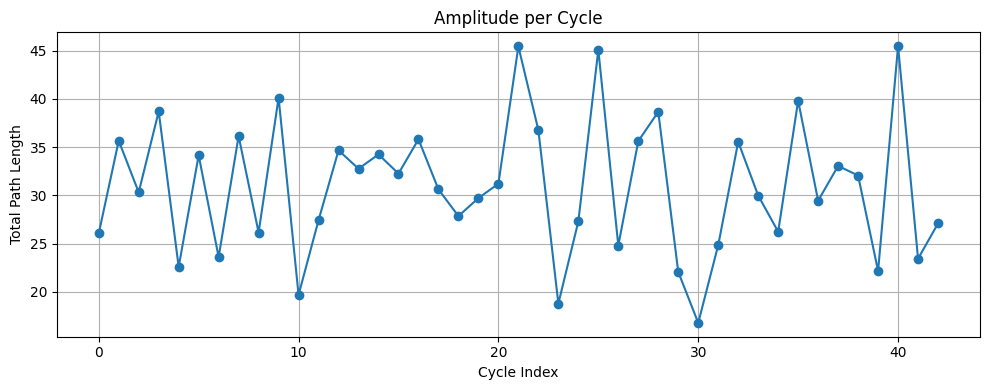

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(amplitude, marker='o')
plt.title("Amplitude per Cycle")
plt.xlabel("Cycle Index")
plt.ylabel("Total Path Length")
plt.grid(True)
plt.tight_layout()
plt.show()


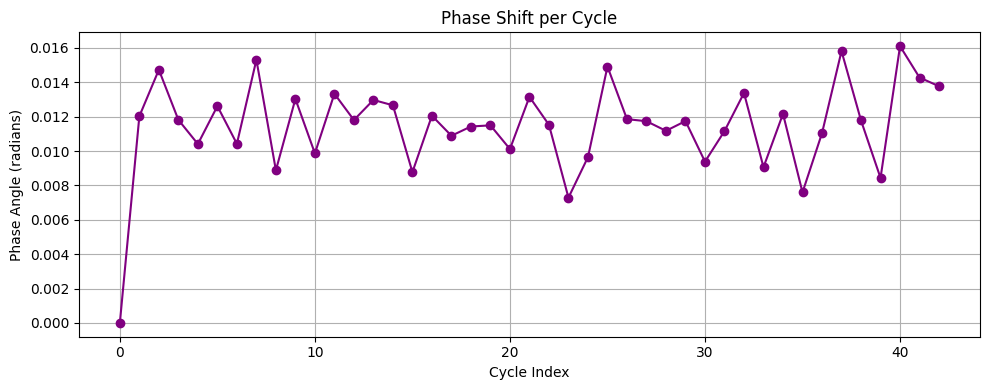

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(phase_angle, marker='o', color='purple')
plt.title("Phase Shift per Cycle")
plt.xlabel("Cycle Index")
plt.ylabel("Phase Angle (radians)")
plt.grid(True)
plt.tight_layout()
plt.show()


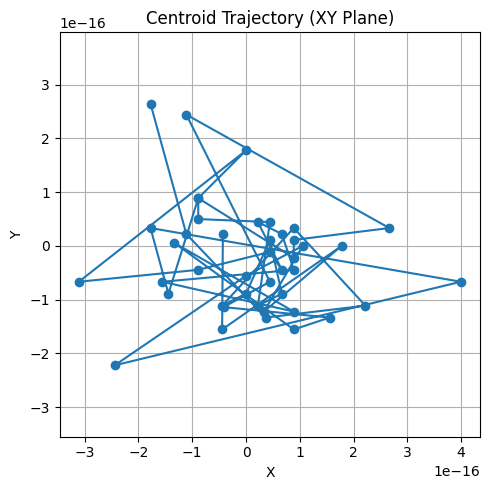

In [18]:
plt.figure(figsize=(5, 5))
plt.plot(centroids[:,0], centroids[:,1], marker='o')
plt.title("Centroid Trajectory (XY Plane)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()


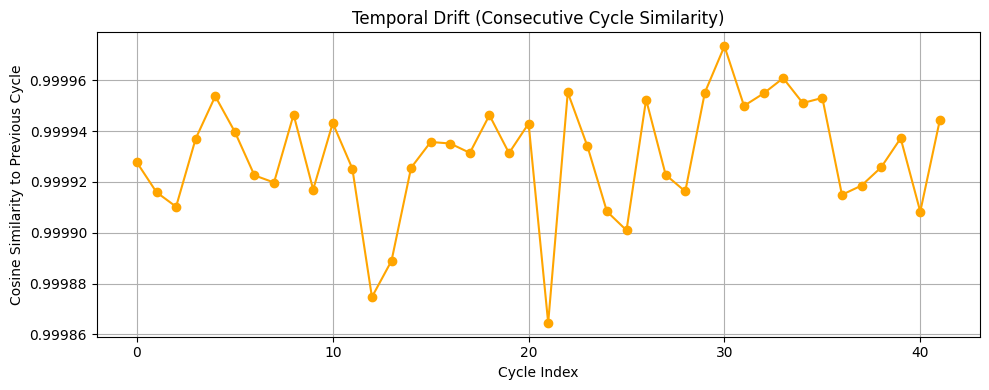

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(temporal_drift, marker='o', color='orange')
plt.title("Temporal Drift (Consecutive Cycle Similarity)")
plt.xlabel("Cycle Index")
plt.ylabel("Cosine Similarity to Previous Cycle")
plt.grid(True)
plt.tight_layout()
plt.show()


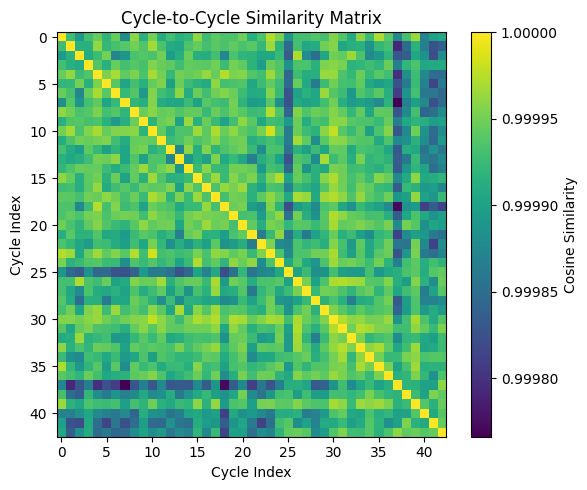

In [20]:
plt.figure(figsize=(6, 5))
plt.imshow(similarity_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='Cosine Similarity')
plt.title("Cycle-to-Cycle Similarity Matrix")
plt.xlabel("Cycle Index")
plt.ylabel("Cycle Index")
plt.tight_layout()
plt.show()


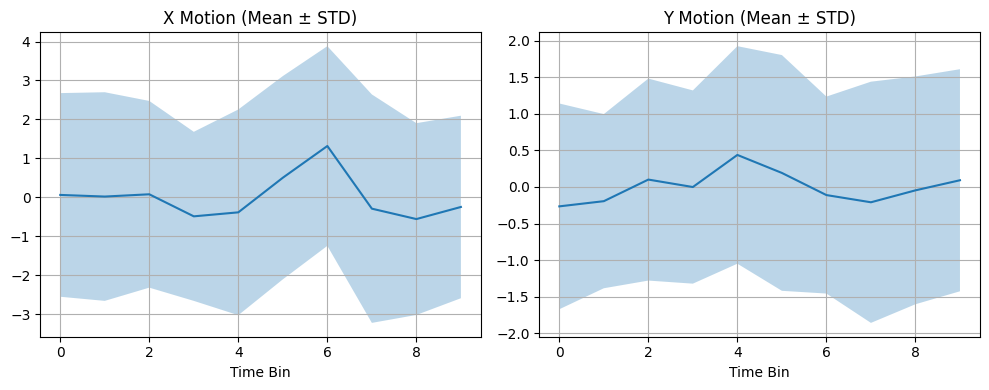

In [21]:
mean_seg = aligned_segments.mean(axis=0)      # 10×2
std_seg  = aligned_segments.std(axis=0)       # 10×2
t = np.arange(10)

plt.figure(figsize=(10, 4))

# X trajectory
plt.subplot(1,2,1)
plt.plot(t, mean_seg[:,0], label="mean X")
plt.fill_between(t, mean_seg[:,0]-std_seg[:,0], mean_seg[:,0]+std_seg[:,0], alpha=0.3)
plt.title("X Motion (Mean ± STD)")
plt.xlabel("Time Bin")
plt.grid(True)

# Y trajectory
plt.subplot(1,2,2)
plt.plot(t, mean_seg[:,1], label="mean Y")
plt.fill_between(t, mean_seg[:,1]-std_seg[:,1], mean_seg[:,1]+std_seg[:,1], alpha=0.3)
plt.title("Y Motion (Mean ± STD)")
plt.xlabel("Time Bin")
plt.grid(True)

plt.tight_layout()
plt.show()


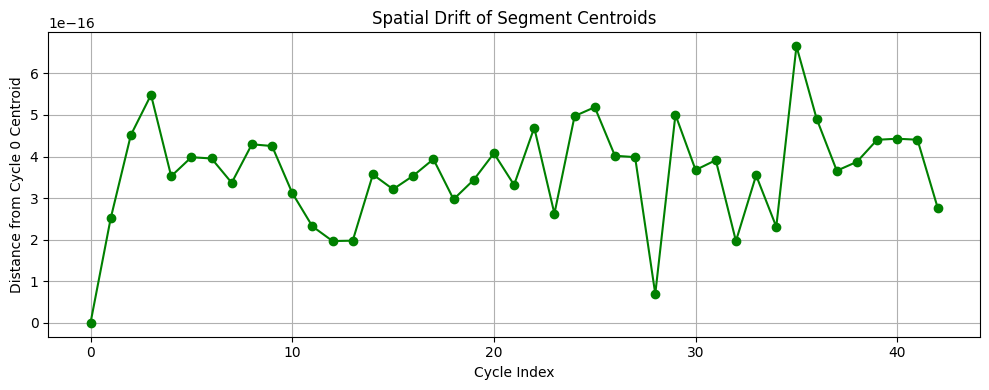

In [22]:
phase_deg = np.degrees(phase_angle)
plt.figure(figsize=(10, 4))
plt.plot(centroid_drift, marker='o', color='green')
plt.title("Spatial Drift of Segment Centroids")
plt.xlabel("Cycle Index")
plt.ylabel("Distance from Cycle 0 Centroid")
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
import numpy as np

def events_to_frames(events, width, height, dt_us=10000):
    """
    Convert events to time-binned frames.
    dt_us: bin size in microseconds (10,000 µs = 10 ms)
    """

    t0 = events[0]['t']
    t_end = events[-1]['t']
    num_frames = (t_end - t0) // dt_us + 1

    frames = np.zeros((num_frames, height, width), dtype=np.int16)

    for e in events:
        t, x, y, p = e['t'], e['x'], e['y'], e['p']
        frame_idx = (t - t0) // dt_us
        frames[frame_idx, y, x] += 1 if p == 1 else -1

    return frames

In [24]:
W, H = 640, 480   # replace with your sensor resolution
frames = events_to_frames(arr, W, H, dt_us=10000)

print("Number of frames:", len(frames))

Number of frames: 4361


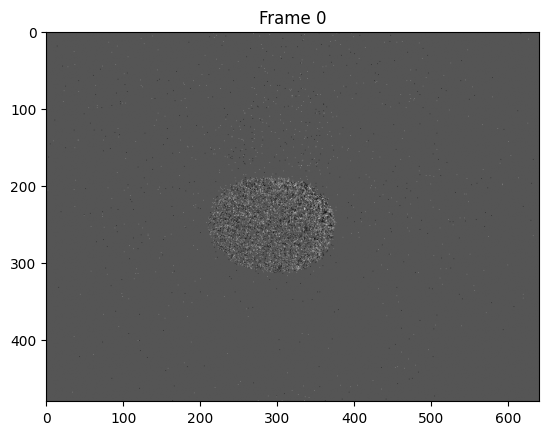

In [25]:
import matplotlib.pyplot as plt

plt.imshow(frames[0], cmap='gray')
plt.title("Frame 0")
plt.show()

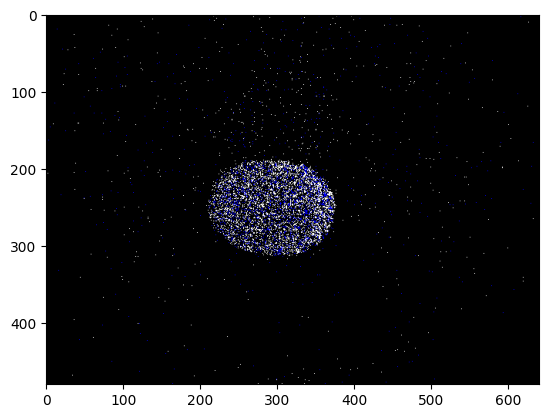

In [26]:
def frame_to_rgb(frame):
    rgb = np.zeros((frame.shape[0], frame.shape[1], 3), dtype=np.uint8)
    rgb[frame > 0] = [255, 255, 255]  # ON
    rgb[frame < 0] = [0, 0, 255]      # OFF
    return rgb

rgb_img = frame_to_rgb(frames[0])
plt.imshow(rgb_img)
plt.show()

In [27]:
frames = events_to_frames(arr, W, H, dt_us=10000)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def play_event_frames_with_timebar(frames, dt_us=10000):
    num_frames, H, W = frames.shape
    duration_s = (num_frames * dt_us) / 1e6

    fig, ax = plt.subplots(figsize=(6, 4))
    img = ax.imshow(frames[0], cmap="gray", vmin=-5, vmax=5, animated=True)
    ax.axis('off')

    # Add time bar axes at the bottom
    bar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.03])
    bar_ax.set_xlim(0, duration_s)
    bar_ax.set_ylim(0, 1)
    bar_ax.axis("off")

    time_bar, = bar_ax.plot([0, 0], [0, 1], linewidth=5)
    time_text = ax.text(10, 10, "", color="yellow", fontsize=12)

    def update(i):
        img.set_data(frames[i])

        current_time = (i * dt_us) / 1e6
        time_bar.set_data([0, current_time], [0.5, 0.5])
        time_text.set_text(f"t = {current_time:.3f} s")

        return img, time_bar, time_text

    ani = FuncAnimation(fig, update, frames=num_frames, interval=10, blit=True)
    plt.show()


In [8]:
import os
import imageio.v3 as iio
import numpy as np

def save_frames_as_jpeg(frames, out_dir="frames_gray"):
    os.makedirs(out_dir, exist_ok=True)

    # Normalize for visualization (avoid too dark images)
    abs_max = np.max(np.abs(frames))
    frames_norm = ((frames / abs_max) * 127 + 128).astype(np.uint8)

    for i, frame in enumerate(frames_norm):
        fpath = os.path.join(out_dir, f"frame_{i:05d}.jpg")
        iio.imwrite(fpath, frame)

    print(f"Saved {len(frames)} JPEG images into {out_dir}/")

save_frames_as_jpeg(frames)



Saved 1537 JPEG images into frames_gray/


In [17]:
def frame_to_rgb(frame):
    H, W = frame.shape
    rgb = np.zeros((H, W, 3), dtype=np.uint8)

    rgb[frame > 0] = [255, 255, 255]   # ON events → white
    rgb[frame < 0] = [0, 0, 255]       # OFF events → blue
    return rgb


def save_frames_rgb(frames, out_dir="frames_rgb"):
    os.makedirs(out_dir, exist_ok=True)

    for i, f in enumerate(frames):
        rgb = frame_to_rgb(f)
        fpath = os.path.join(out_dir, f"frame_{i:05d}.jpg")
        iio.imwrite(fpath, rgb)

    print(f"Saved {len(frames)} RGB JPEG images into {out_dir}/")

save_frames_rgb(frames)


Saved 4361 RGB JPEG images into frames_rgb/


In [18]:
import cv2
import numpy as np

def frames_to_video(frames, out_path="output.mp4", fps=30):
    """
    frames: numpy array of shape (N, H, W) or (N, H, W, 3)
    """
    num_frames = len(frames)

    # Determine if grayscale or RGB
    if frames.ndim == 3:        # (N, H, W)
        H, W = frames[0].shape
        is_color = False
    elif frames.ndim == 4:      # (N, H, W, 3)
        H, W, _ = frames[0].shape
        is_color = True
    else:
        raise ValueError("Frames must be (N,H,W) or (N,H,W,3)")

    # Video writer
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H), isColor=is_color)

    for i in range(num_frames):
        frame = frames[i]

        # Convert grayscale to BGR for OpenCV
        if not is_color:
            frame = cv2.cvtColor(frame.astype(np.uint8), cv2.COLOR_GRAY2BGR)
        else:
            frame = frame.astype(np.uint8)[:, :, ::-1]  # RGB → BGR

        writer.write(frame)

    writer.release()
    print(f"Saved video: {out_path}")


In [19]:
rgb_frames = np.array([frame_to_rgb(f) for f in frames])
frames_to_video(rgb_frames, "events_rgb.mp4", fps=30)

Saved video: events_rgb.mp4


In [21]:
import numpy as np
import cv2

def compute_density_map(frames):
    """
    frames: (N, H, W)
    Returns a 2D density map (H, W)
    """
    # Sum absolute activity to avoid polarity cancellation
    density = np.sum(np.abs(frames), axis=0)
    return density

def threshold_density(density):
    density_norm = (density / density.max() * 255).astype(np.uint8)
    _, mask = cv2.threshold(density_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask

def mask_to_bbox(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        raise ValueError("No region detected")

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    return (x_min, x_max, y_min, y_max)

def crop_frames(frames, bbox):
    x_min, x_max, y_min, y_max = bbox
    return frames[:, y_min:y_max+1, x_min:x_max+1]


density = compute_density_map(frames)
mask = threshold_density(density)
bbox = mask_to_bbox(mask)
cropped_frames = crop_frames(frames, bbox)

print("Bounding box:", bbox)
print("Original shape:", frames.shape)
print("Cropped shape:", cropped_frames.shape)


Bounding box: (np.int64(47), np.int64(608), np.int64(1), np.int64(479))
Original shape: (4361, 480, 640)
Cropped shape: (4361, 479, 562)


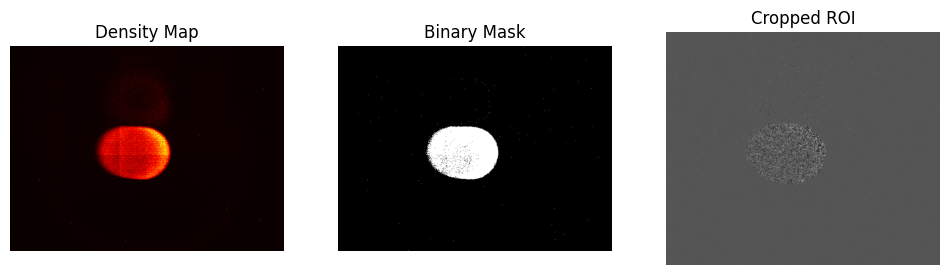

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Density Map")
plt.imshow(density, cmap='hot')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Binary Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Cropped ROI")
plt.imshow(cropped_frames[0], cmap='gray')
plt.axis("off")

plt.show()


In [31]:
def compute_density_map(frames):
    return np.sum(np.abs(frames), axis=0)
def bright_region_mask(density, percentile=99):
    thr = np.percentile(density, percentile)
    mask = (density >= thr).astype(np.uint8) * 255
    return mask
import cv2

def clean_mask(mask):
    # Remove noise
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Fill holes + expand region to get full ROI
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Optional: dilate to give a margin around the object
    mask = cv2.dilate(mask, kernel, iterations=3)
    return mask
def mask_to_bbox(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        raise ValueError("No bright region detected!")

    return xs.min(), xs.max(), ys.min(), ys.max()
def crop_frames(frames, bbox):
    x1, x2, y1, y2 = bbox
    return frames[:, y1:y2+1, x1:x2+1]
density = compute_density_map(frames)
mask = bright_region_mask(density, percentile=90)
mask = clean_mask(mask)
bbox = mask_to_bbox(mask)
cropped_frames = crop_frames(frames, bbox)

print("Selected region:", bbox)
print("Original:", frames.shape, " → Cropped:", cropped_frames.shape)


Selected region: (np.int64(194), np.int64(382), np.int64(181), np.int64(320))
Original: (4361, 480, 640)  → Cropped: (4361, 140, 189)


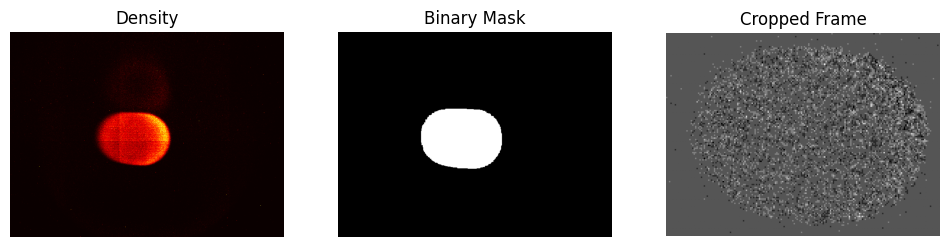

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Density")
plt.imshow(density, cmap="hot")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Binary Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Cropped Frame")
plt.imshow(cropped_frames[0], cmap="gray")
plt.axis("off")

plt.show()
